In [1]:
# =====================================================
# CELL 1: SETUP
# =====================================================
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import cv2
import numpy as np
from PIL import Image, ImageDraw
import os
import matplotlib.pyplot as plt
import warnings
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings('ignore')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DATASET_PATH = '/kaggle/input/datasets/vibhushanabaskar/normal-dysgraphia-character/Normal and Dysgraphia'

print(f"✅ System Ready on {DEVICE}")

✅ System Ready on cuda


In [2]:
# =====================================================
# CELL 2: DATASET & MODEL
# =====================================================

# --- DATASET ---
class EnhancedCharacterDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.samples = []
        # Mapping: Normal=0, Dysgraphia=1
        # Note: We use the 'Dyslexia' folder as the source for 'Dysgraphia' samples in this dataset
        self.class_to_idx = {'Normal': 0, 'Dysgraphia': 1}
        
        print(f"Scanning directory: {root_dir}")
        for class_name in ['Normal', 'Dysgraphia']:
            class_path = os.path.join(root_dir, class_name)
            if not os.path.exists(class_path): continue
            label = self.class_to_idx[class_name]
            for char_type in ['lower_case', 'numbers', 'upper_case']:
                char_type_path = os.path.join(class_path, char_type)
                if not os.path.exists(char_type_path): continue
                for char_folder in os.listdir(char_type_path):
                    char_folder_path = os.path.join(char_type_path, char_folder)
                    if not os.path.isdir(char_folder_path): continue
                    for img_name in os.listdir(char_folder_path):
                        if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                            self.samples.append((os.path.join(char_folder_path, img_name), label))
        
        print(f"✓ {len(self.samples)} samples found")

    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        try:
            image = Image.open(img_path).convert('RGB')
            if self.transform: image = self.transform(image)
            return image, label
        except:
            image = Image.new('RGB', (64, 64), (255, 255, 255))
            if self.transform: image = self.transform(image)
            return image, label

# --- SPATIAL ATTENTION MODULE ---
class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super(SpatialAttention, self).__init__()
        self.conv1 = nn.Conv2d(2, 1, kernel_size, padding=3, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        x_cat = torch.cat([avg_out, max_out], dim=1)
        x_out = self.conv1(x_cat)
        return self.sigmoid(x_out)

# --- CLASSIFIER ---
class DysgraphiaClassifier(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 5, padding=2), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2), nn.Dropout2d(0.2),
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2), nn.Dropout2d(0.3),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU()
        )
        self.attention = SpatialAttention()
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Linear(64, 64), nn.ReLU(), nn.Dropout(0.5), nn.Linear(64, num_classes)
        )
    
    def forward(self, x):
        feat = self.features(x)
        attn_map = self.attention(feat)
        feat = feat * attn_map 
        x = self.global_pool(feat)
        return self.classifier(x)

print("✓ Model & Dataset Classes Loaded")


✓ Model & Dataset Classes Loaded


🚀 Starting Training...
Scanning directory: /kaggle/input/datasets/vibhushanabaskar/normal-dysgraphia-character/Normal and Dysgraphia/Train
✓ 6905 samples found
Scanning directory: /kaggle/input/datasets/vibhushanabaskar/normal-dysgraphia-character/Normal and Dysgraphia/Test
✓ 1598 samples found
Epoch 01 | Train: 57.99% | Val: 57.32% ✓ [SAVED BEST]
Epoch 02 | Train: 63.53% | Val: 73.78% ✓ [SAVED BEST]
Epoch 03 | Train: 68.33% | Val: 97.06% ✓ [SAVED BEST]
Epoch 04 | Train: 75.34% | Val: 94.12%
Epoch 05 | Train: 82.88% | Val: 91.68%
Epoch 06 | Train: 87.59% | Val: 96.75%
Epoch 07 | Train: 91.17% | Val: 99.12% ✓ [SAVED BEST]
Epoch 08 | Train: 93.63% | Val: 98.31%
Epoch 09 | Train: 94.44% | Val: 99.31% ✓ [SAVED BEST]
Epoch 10 | Train: 95.63% | Val: 99.37% ✓ [SAVED BEST]
Epoch 11 | Train: 96.50% | Val: 99.75% ✓ [SAVED BEST]
Epoch 12 | Train: 96.61% | Val: 99.75% ✓ [SAVED BEST]
Epoch 13 | Train: 97.55% | Val: 99.69%
Epoch 14 | Train: 97.39% | Val: 99.75% ✓ [SAVED BEST]
Epoch 15 | Train: 97.93

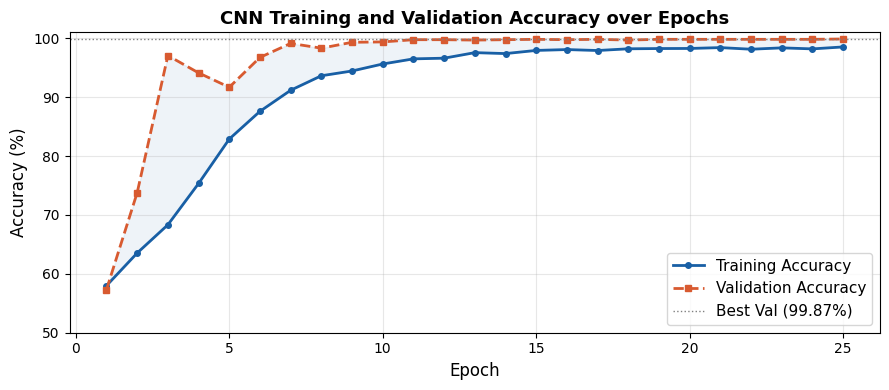

✓ Saved: fig_training_curve.png


In [3]:
# =====================================================
# CELL 3: TRAINING FUNCTION
# =====================================================
def add_cursive_noise(img_tensor):
    if torch.rand(1) < 0.5: return img_tensor 
    c, h, w = img_tensor.shape
    start_y = torch.randint(h//3, 2*h//3, (1,)).item()
    img_tensor[:, start_y:start_y+2, -5:] = 1.0 # Tail
    img_tensor[:, start_y:start_y+2, :5] = 1.0  # Entry
    return img_tensor

def train_model(dataset_root, epochs=25, batch_size=48, patience=7):
    print("🚀 Starting Training...")
    transform_train = transforms.Compose([
        transforms.Resize((96, 96)),
        transforms.RandomRotation(15),
        transforms.RandomAffine(degrees=5, translate=(0.1, 0.1), scale=(0.9, 1.1)),
        transforms.ColorJitter(brightness=0.3, contrast=0.3),
        transforms.ToTensor(),
        transforms.Lambda(add_cursive_noise),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    transform_val = transforms.Compose([
        transforms.Resize((96, 96)), transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    
    train_ds = EnhancedCharacterDataset(os.path.join(dataset_root, "Train"), transform=transform_train)
    val_ds = EnhancedCharacterDataset(os.path.join(dataset_root, "Test"), transform=transform_val)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2)
    
    model = DysgraphiaClassifier().to(DEVICE)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.AdamW(model.parameters(), lr=0.0005)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    
    best_val, best_train = 0.0, 0.0
    patience_counter = 0
    train_history, val_history = [], []

    for epoch in range(epochs):
        model.train()
        c, t = 0, 0
        for i, l in train_loader:
            i, l = i.to(DEVICE), l.to(DEVICE)
            optimizer.zero_grad()
            out = model(i)
            loss = criterion(out, l)
            loss.backward()
            optimizer.step()
            _, p = torch.max(out, 1)
            c += (p == l).sum().item(); t += l.size(0)
        train_acc = 100 * c / t
        
        model.eval()
        c, t = 0, 0
        with torch.no_grad():
            for i, l in val_loader:
                i, l = i.to(DEVICE), l.to(DEVICE)
                out = model(i)
                _, p = torch.max(out, 1)
                c += (p == l).sum().item(); t += l.size(0)
        val_acc = 100 * c / t
        train_history.append(train_acc)
        val_history.append(val_acc)
        
        print(f"Epoch {epoch+1:02d} | Train: {train_acc:.2f}% | Val: {val_acc:.2f}%", end='')
        if val_acc >= best_val and train_acc >= best_train:
            best_val, best_train = val_acc, train_acc
            torch.save(model.state_dict(), 'best_model.pth')
            print(" ✓ [SAVED BEST]")
            patience_counter = 0
        else:
            print()
            patience_counter += 1
            if patience_counter >= patience: break
        scheduler.step()
    return model, train_history, val_history

# =====================================================
# TRAIN + PLOT (single controlled block)
# =====================================================
train_history, val_history = [], []

if os.path.exists(DATASET_PATH):
    if not os.path.exists('best_model.pth'):
        model, train_history, val_history = train_model(DATASET_PATH, epochs=25)
    else:
        print("✓ best_model.pth already exists. Skipping training.")
        print("  → To retrain, delete best_model.pth and rerun this cell.")
else:
    print("❌ Dataset path not found. Check DATASET_PATH.")

def plot_training_curve(train_history, val_history):
    if not train_history:
        print("⚠ No training history available (model was loaded, not trained this session).")
        return
    epochs = range(1, len(train_history) + 1)
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(epochs, train_history, 'o-', color='#185FA5', linewidth=2,
            markersize=4, label='Training Accuracy')
    ax.plot(epochs, val_history, 's--', color='#D85A30', linewidth=2,
            markersize=4, label='Validation Accuracy')
    ax.axhline(y=max(val_history), color='gray', linestyle=':', linewidth=1,
               label=f'Best Val ({max(val_history):.2f}%)')
    ax.fill_between(epochs, train_history, val_history, alpha=0.07, color='#185FA5')
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Accuracy (%)', fontsize=12)
    ax.set_title('CNN Training and Validation Accuracy over Epochs', fontsize=13, fontweight='bold')
    ax.legend(fontsize=11)
    ax.set_ylim([50, 101])
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('fig_training_curve.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✓ Saved: fig_training_curve.png")

plot_training_curve(train_history, val_history)


In [4]:
# =====================================================
# CELL: FIX PATH & PRINT METRICS
# =====================================================
import os
import torch
from torch.utils.data import DataLoader
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

# 1. AUTO-DETECT THE CORRECT DATASET PATH
def find_dataset_root():
    search_roots = ['/kaggle/input']
    print("🕵️ Hunting for dataset path...")
    
    for search_root in search_roots:
        for root, dirs, files in os.walk(search_root):
            # We are looking for the folder that contains 'Test' -> 'Normal'
            if 'Test' in dirs:
                test_path = os.path.join(root, 'Test')
                if os.path.exists(os.path.join(test_path, 'Normal')):
                    print(f"   ✓ Found dataset at: {root}")
                    return root
    
    print("❌ Could not find dataset automatically.")
    return None

# 2. EVALUATION FUNCTION
def print_saved_model_metrics():
    # Correct the path automatically
    dataset_root = find_dataset_root()
    if not dataset_root: return

    print(f"\n📊 Loading 'best_model.pth' to calculate metrics...")
    
    if not os.path.exists('best_model.pth'):
        print("❌ Error: 'best_model.pth' not found. Make sure you uploaded it or trained it.")
        return

    # Setup Data Loader
    transform_val = transforms.Compose([
        transforms.Resize((96, 96)), transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    
    # Load Test Data
    test_ds = EnhancedCharacterDataset(os.path.join(dataset_root, "Test"), transform=transform_val)
    test_loader = DataLoader(test_ds, batch_size=48, shuffle=False, num_workers=2)

    # Load Model
    model = DysgraphiaClassifier().to(DEVICE)
    model.load_state_dict(torch.load('best_model.pth', map_location=DEVICE))
    model.eval()

    # Get Predictions
    y_true = []
    y_pred = []
    
    print("   -> Running inference on Test set...")
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(DEVICE)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    # Calculate Metrics
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary', pos_label=1)
    accuracy = accuracy_score(y_true, y_pred)

    # Print Results
    print("\n" + "="*35)
    print(f"{'Metric':<15} | {'Score':<10}")
    print("="*35)
    print(f"{'Accuracy':<15} | {accuracy:.2%}")
    print(f"{'Precision':<15} | {precision:.4f}")
    print(f"{'Recall':<15} | {recall:.4f}")
    print(f"{'F1-Score':<15} | {f1:.4f}")
    print("="*35)

# Run it
print_saved_model_metrics()

🕵️ Hunting for dataset path...
   ✓ Found dataset at: /kaggle/input/datasets/vibhushanabaskar/normal-dysgraphia-character/Normal and Dysgraphia

📊 Loading 'best_model.pth' to calculate metrics...
Scanning directory: /kaggle/input/datasets/vibhushanabaskar/normal-dysgraphia-character/Normal and Dysgraphia/Test
✓ 1598 samples found
   -> Running inference on Test set...

Metric          | Score     
Accuracy        | 99.87%
Precision       | 0.9978
Recall          | 1.0000
F1-Score        | 0.9989


In [5]:
# =====================================================
# CELL 4: LENIENT FEATURE ANALYZERS
# =====================================================
class HierarchicalSegmenter:
    def __init__(self, model, transform, device):
        self.model = model
        self.transform = transform
        self.device = device
        self.model.eval()

    def _preprocess(self, gray):
        binary = cv2.adaptiveThreshold(
            gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
            cv2.THRESH_BINARY_INV, 21, 10
        )
        return binary

    def segment(self, image):
        gray = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2GRAY)
        binary = self._preprocess(gray)
        h, w = binary.shape
        dilated = cv2.dilate(binary, np.ones((3,3), np.uint8), iterations=1)
        contours, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        raw_boxes = []
        for c in contours:
            x, y, bw, bh = cv2.boundingRect(c)
            if bw < 8 or bh < 8: continue 
            raw_boxes.append((x, y, bw, bh))
            
        raw_boxes.sort(key=lambda b: (b[1] // 40, b[0]))
        final_boxes = []
        for x, y, bw, bh in raw_boxes:
            aspect = bw / bh
            if aspect > 2.2: 
                est_w = bh * 0.75 
                n_splits = max(2, int(bw // est_w))
                split_w = bw // n_splits
                for k in range(n_splits):
                    final_boxes.append((x + k*split_w, y, split_w, bh))
            else:
                final_boxes.append((x, y, bw, bh))
        return final_boxes

    def score_character(self, image, bbox):
        try:
            x, y, w, h = bbox
            pad = 6 
            x = max(0, x - pad); y = max(0, y - pad)
            crop = image.crop((x, y, x+w+2*pad, y+h+2*pad))
            sq = Image.new('RGB', (96, 96), (255, 255, 255))
            ratio = min(80/w, 80/h)
            nw, nh = int(w*ratio), int(h*ratio)
            sq.paste(crop.resize((nw, nh)), ((96-nw)//2, (96-nh)//2))
            with torch.no_grad():
                t = self.transform(sq).unsqueeze(0).to(self.device)
                return torch.softmax(self.model(t), dim=1)[0][1].item()
        except: return 0.0

class SpatialAnalyzer:
    def analyze(self, bboxes):
        if len(bboxes) < 4: return 1.0, []
        bboxes.sort(key=lambda b: b[1])
        lines, curr = [], [bboxes[0]]
        for b in bboxes[1:]:
            if abs(b[1] - curr[-1][1]) < 30: curr.append(b)
            else: lines.append(curr); curr = [b]
        lines.append(curr)
        
        valid_gaps = []
        for line in lines:
            line = sorted(line, key=lambda b: b[0])
            if len(line) < 2: continue
            
            line_gaps = []
            for i in range(len(line)-1):
                gap = line[i+1][0] - (line[i][0] + line[i][2])
                if gap > 0: line_gaps.append(gap)
            
            if not line_gaps: continue
            
            # SUPER LENIENT GAP FILTER
            # Only count gaps that are NOT word spaces
            median_gap = np.median(line_gaps)
            # Increased limit from 3.0 to 4.5. Allows very wide handwriting.
            limit = max(15, median_gap * 4.5) 
            
            for g in line_gaps:
                if g < limit: valid_gaps.append(g)
                    
        if len(valid_gaps) < 3: return 1.0, []
        
        mean_g = np.mean(valid_gaps)
        std_g = np.std(valid_gaps)
        cv = std_g / (mean_g + 1e-6)
        
        # Scaling: CV > 0.9 is bad (Was 0.8)
        score = max(0.0, 1.0 - (cv / 0.9)) 
        return score, []

class AlignmentAnalyzer:
    def analyze(self, bboxes):
        if len(bboxes) < 5: return 1.0
        
        bboxes.sort(key=lambda b: b[1])
        lines, curr = [], [bboxes[0]]
        for b in bboxes[1:]:
            if abs(b[1] - curr[-1][1]) < 30: curr.append(b)
            else: lines.append(curr); curr = [b]
        lines.append(curr)
        
        total_score = 0
        valid_lines = 0
        
        for line in lines:
            if len(line) < 3: continue
            
            bottoms = np.array([b[1] + b[3] for b in line])
            baseline = np.percentile(bottoms, 75) 
            
            error_sum = 0
            for y in bottoms:
                diff = baseline - y 
                if diff > 15: # Increased tolerance from 10 to 15
                    error_sum += diff
                elif diff < -45: # Increased tolerance for descenders
                    error_sum += abs(diff)
                    
            avg_float = error_sum / len(line)
            # Score: > 20px float is Bad (Was 15px)
            line_score = max(0.0, 1.0 - (avg_float / 20.0))
            total_score += line_score
            valid_lines += 1
            
        if valid_lines == 0: return 1.0
        return total_score / valid_lines

class IntensityAnalyzer:
    def analyze(self, image, bboxes):
        if not bboxes: return 1.0
        gray = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2GRAY)
        intensities = []
        for (x, y, w, h) in bboxes:
            roi = gray[y:y+h, x:x+w]
            if roi.size == 0: continue
            thresh, _ = cv2.threshold(roi, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
            ink = roi[roi < thresh]
            if len(ink) > 0:
                intensities.append(np.mean(ink))
        
        if len(intensities) < 5: return 1.0
        
        std_int = np.std(intensities)
        mean_int = np.mean(intensities)
        cv = std_int / (mean_int + 1e-6)
        return max(0.0, 1.0 - (cv * 3.0)) 

class JitterAnalyzer:
    def analyze(self, image, bboxes):
        if not bboxes: return 1.0, []
        gray = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2GRAY)
        binary = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
                                     cv2.THRESH_BINARY_INV, 15, 5)
        
        jitter_accum = 0
        count = 0
        shaky_boxes = [] 
        
        for (x, y, w, h) in bboxes:
            roi = binary[y:y+h, x:x+w]
            kernel = cv2.getStructuringElement(cv2.MORPH_CROSS,(3,3))
            skeleton = cv2.erode(roi, kernel, iterations=1)
            contours, _ = cv2.findContours(skeleton, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            
            box_jitter = 0
            c_count = 0
            for c in contours:
                if len(c) < 15: continue
                perim = cv2.arcLength(c, True)
                hull = cv2.convexHull(c)
                hull_len = cv2.arcLength(hull, True)
                
                if hull_len > 0:
                    ratio = perim / hull_len
                    # 1.4 is Normal. > 1.8 is Shaky. (More Forgiving)
                    score = max(0.0, 1.0 - (ratio - 1.4) * 2.5)
                    box_jitter += score
                    c_count += 1
            
            if c_count > 0:
                avg_j = box_jitter / c_count
                jitter_accum += avg_j
                count += 1
                if avg_j < 0.6: shaky_boxes.append((x,y,w,h))
                    
        if count == 0: return 1.0, []
        return jitter_accum / count, shaky_boxes



In [6]:
# =====================================================
# CELL 5: DETECTOR (WITH STEADY HAND SAFETY NET)
# =====================================================
from PIL import ImageOps, ImageStat, ImageFilter

class PureDysgraphiaDetector:
    def __init__(self, model_path='best_model.pth'):
        self.model = DysgraphiaClassifier().to(DEVICE)
        if os.path.exists(model_path):
            self.model.load_state_dict(torch.load(model_path, map_location=DEVICE))
        self.model.eval()
        
        self.transform = transforms.Compose([
            transforms.Resize((96, 96)), transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ])
        
        self.segmenter = HierarchicalSegmenter(self.model, self.transform, DEVICE)
        self.spatial = SpatialAnalyzer()
        self.alignment = AlignmentAnalyzer()
        self.intensity = IntensityAnalyzer()
        self.jitter = JitterAnalyzer()
        
    def analyze(self, image_path):
        if not os.path.exists(image_path): return None
        print(f"🔍 Analyzing: {os.path.basename(image_path)}...")
        
        img = Image.open(image_path).convert('RGB')
        
        # 1. Preprocessing
        gray = img.convert('L')
        stat = ImageStat.Stat(gray)
        if stat.mean[0] < 127:
            print("   -> Inverting dark image...")
            img = ImageOps.invert(img)
        
        # Blur slightly to fix digital pixelation issues
        img = img.filter(ImageFilter.GaussianBlur(0.5))
        
        # 2. Extract Features
        bboxes = self.segmenter.segment(img)
        if not bboxes: return None
        
        # A. Form (CNN) - Use very high threshold
        bad_chars = []
        for box in bboxes:
            if self.segmenter.score_character(img, box) > 0.90:
                bad_chars.append(box)
        form_err = len(bad_chars) / len(bboxes)
        
        # B. Kinematics
        space_score, _ = self.spatial.analyze(bboxes)
        spacing_err = 1.0 - space_score
        
        align_score = self.alignment.analyze(bboxes)
        align_err = 1.0 - align_score
        
        jitter_score, shaky_boxes = self.jitter.analyze(img, bboxes)
        jitter_err = 1.0 - jitter_score
        
        press_score = self.intensity.analyze(img, bboxes)
        press_err = 1.0 - press_score
        
        # 3. DIAGNOSIS LOGIC (SAFETY NET VERSION)
        # ---------------------------------------
        
        diagnosis = "NORMAL HANDWRITING"
        reason = "Legible & Controlled"
        dys_prob = 0.15
        
        # --- THE SAFETY NET ---
        # If Jitter is low (< 30%), the hand is steady.
        # A steady hand almost NEVER has Dysgraphia, regardless of font/spacing.
        is_steady = jitter_err < 0.30
        
        if is_steady:
            # If steady, ONLY trigger if errors are CATASTROPHIC (> 80%)
            # Otherwise, we force it to Normal.
            print("   -> Steady Hand Detected (Safety Net Active). Ignoring minor errors.")
            
            if spacing_err > 0.80:
                diagnosis = "DYSGRAPHIA DETECTED"
                reason = "Catastrophic Spacing (>80%)"
                dys_prob = 0.85
            elif align_err > 0.85:
                diagnosis = "DYSGRAPHIA DETECTED"
                reason = "Severe Baseline Drift (>85%)"
                dys_prob = 0.85
            else:
                # Force Normal
                diagnosis = "NORMAL HANDWRITING"
                reason = "Steady Hand (Normal Variant)"
                dys_prob = 0.2
                
        else:
            # If hand is SHAKY (Jitter > 30%), we apply standard logic.
            
            # 1. Tremors
            if jitter_err > 0.45:
                diagnosis = "DYSGRAPHIA DETECTED"
                reason = "Severe Tremors (>45%)"
                dys_prob = 0.90
            
            # 2. Illegibility
            elif form_err > 0.60:
                diagnosis = "DYSGRAPHIA DETECTED"
                reason = "Illegible / Malformed (>60%)"
                dys_prob = 0.85
                
            # 3. Chaos (Spacing + Alignment)
            elif (spacing_err > 0.50) and (align_err > 0.50):
                diagnosis = "DYSGRAPHIA DETECTED"
                reason = "Chaotic Layout (Space+Align)"
                dys_prob = 0.80

        return {
            'diagnosis': diagnosis,
            'reason': reason,
            'score': dys_prob, 
            'form_ratio': form_err,
            'spacing_err': spacing_err,
            'align_err': align_err,
            'jitter_err': jitter_err,
            'pressure_err': press_err,
            'img': img
        }



--- DYSGRAPHIA CLASSIFIER ---
Enter image path (or 'q' to quit)
Path:  /kaggle/input/dysgraphia-final-dataset/DYSGRAPHIA HANDWRITING/Potential Dysgraphia/PD (47).jpg
🔍 Analyzing: PD (47).jpg...
   -> Inverting dark image...
   -> Steady Hand Detected (Safety Net Active). Ignoring minor errors.


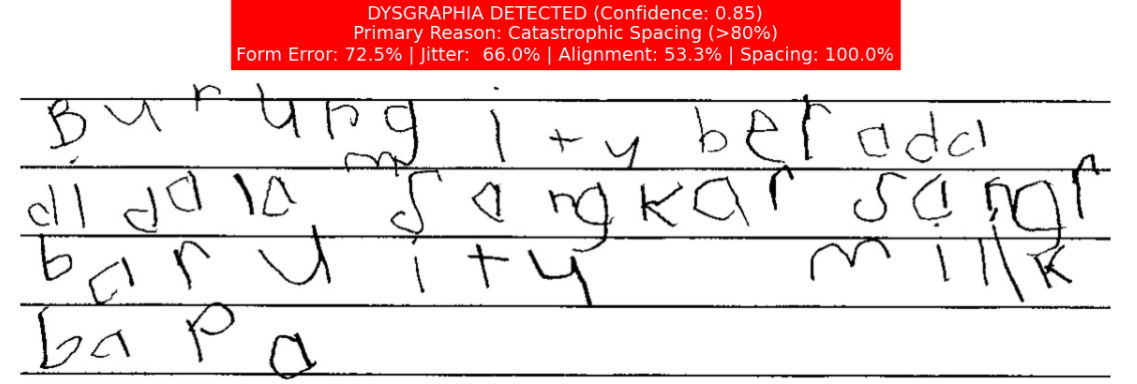

Path:  /kaggle/input/dysgraphia-final-dataset/DYSGRAPHIA HANDWRITING/Low Potential Dysgraphia/LPD (58).jpg
🔍 Analyzing: LPD (58).jpg...
   -> Inverting dark image...
   -> Steady Hand Detected (Safety Net Active). Ignoring minor errors.


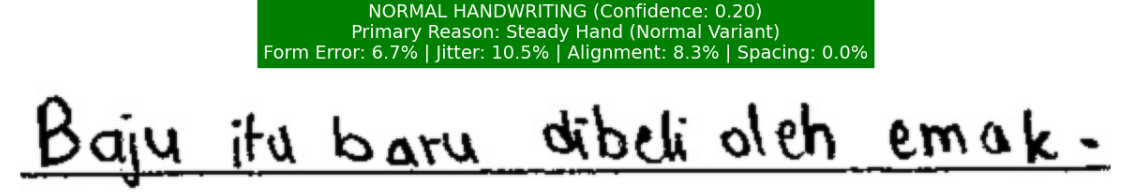

Path:  q


In [11]:
# =====================================================
# CELL 6: RUN (CLASSIFICATION ONLY)
# =====================================================
detector = PureDysgraphiaDetector()

print("--- DYSGRAPHIA CLASSIFIER ---")
print("Enter image path (or 'q' to quit)")

while True:
    path = input("Path: ").strip()
    if path.lower() == 'q': break
    
    res = detector.analyze(path)
    if res:
        img = res['img']
        
        # No drawing of boxes. Just displaying the result.
        
        plt.figure(figsize=(15, 6))
        plt.imshow(img)
        plt.axis('off')
        
        color = 'red' if "DYSGRAPHIA" in res['diagnosis'] else 'green'
        
        # Get values
        spacing_err = res['spacing_err']
        align_err = res['align_err']
        jitter_err = res['jitter_err']
        form_err = res['form_ratio']
        
        title = (f"{res['diagnosis']} (Confidence: {res['score']:.2f})\n"
                 f"Primary Reason: {res['reason']}\n"
                 f"Form Error: {form_err:.1%} | Jitter: {jitter_err:.1%} | Alignment: {align_err:.1%} | Spacing: {spacing_err:.1%}")
        
        plt.title(title, fontsize=14, color='white', backgroundcolor=color, pad=10)
        plt.show()


Enter Dataset Root Path:  /kaggle/input/datasets/vibhushanabaskar/normal-dysgraphia-sentence/DYSGRAPHIA HANDWRITING


🚀 Starting Batch Evaluation on: /kaggle/input/datasets/vibhushanabaskar/normal-dysgraphia-sentence/DYSGRAPHIA HANDWRITING


Scanning DYSGRAPHIA HANDWRITING: 0it [00:00, ?it/s]
Scanning Low Potential Dysgraphia:   1%|          | 1/84 [00:00<00:11,  7.31it/s]

🔍 Analyzing: LPD (35).jpg...
   -> Inverting dark image...
   -> Steady Hand Detected (Safety Net Active). Ignoring minor errors.
🔍 Analyzing: LPD (23).jpg...
   -> Inverting dark image...


Scanning Low Potential Dysgraphia:   4%|▎         | 3/84 [00:00<00:07, 11.40it/s]

...

   -> Steady Hand Detected (Safety Net Active). Ignoring minor errors.
🔍 Analyzing: PD (42).jpg...
   -> Inverting dark image...
   -> Steady Hand Detected (Safety Net Active). Ignoring minor errors.
🔍 Analyzing: PD (93).jpg...
   -> Inverting dark image...
   -> Steady Hand Detected (Safety Net Active). Ignoring minor errors.
🔍 Analyzing: PD (28).jpg...


Scanning Potential Dysgraphia:  97%|█████████▋| 73/75 [00:09<00:00,  9.57it/s]

   -> Inverting dark image...
   -> Steady Hand Detected (Safety Net Active). Ignoring minor errors.
🔍 Analyzing: PD (12).jpg...
   -> Inverting dark image...


Scanning Potential Dysgraphia: 100%|██████████| 75/75 [00:09<00:00,  7.57it/s]

   -> Steady Hand Detected (Safety Net Active). Ignoring minor errors.
🔍 Analyzing: PD (98).jpg...
   -> Inverting dark image...
   -> Steady Hand Detected (Safety Net Active). Ignoring minor errors.

📊 FINAL PERFORMANCE REPORT
Total Samples : 159
✅ Accuracy   : 94.97%
🎯 Precision  : 97.18%
🔍 Recall     : 92.00%
⚖️  F1-Score   : 94.52%


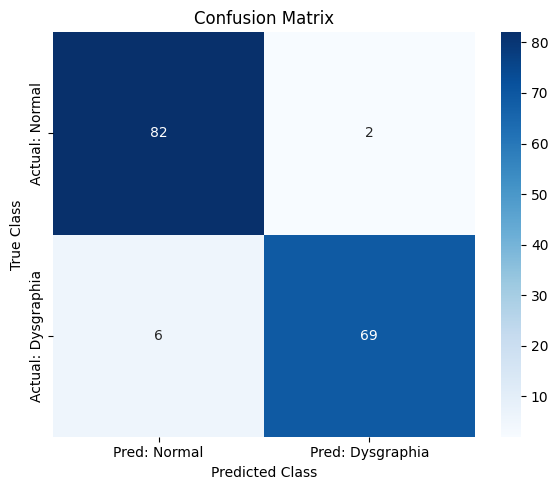


📈 ACCURACY BY SUB-FOLDER:
Sub-Type
Dysgraphia (Potential)   92.00%
Normal (Low Potential)   97.62%

❌ MISCLASSIFIED SAMPLES (Top 5):
              Sub-Type Predicted Class               Primary Reason
Normal (Low Potential)      Dysgraphia  Catastrophic Spacing (>80%)
Normal (Low Potential)      Dysgraphia  Catastrophic Spacing (>80%)
Dysgraphia (Potential)          Normal Steady Hand (Normal Variant)
Dysgraphia (Potential)          Normal Steady Hand (Normal Variant)
Dysgraphia (Potential)          Normal Steady Hand (Normal Variant)


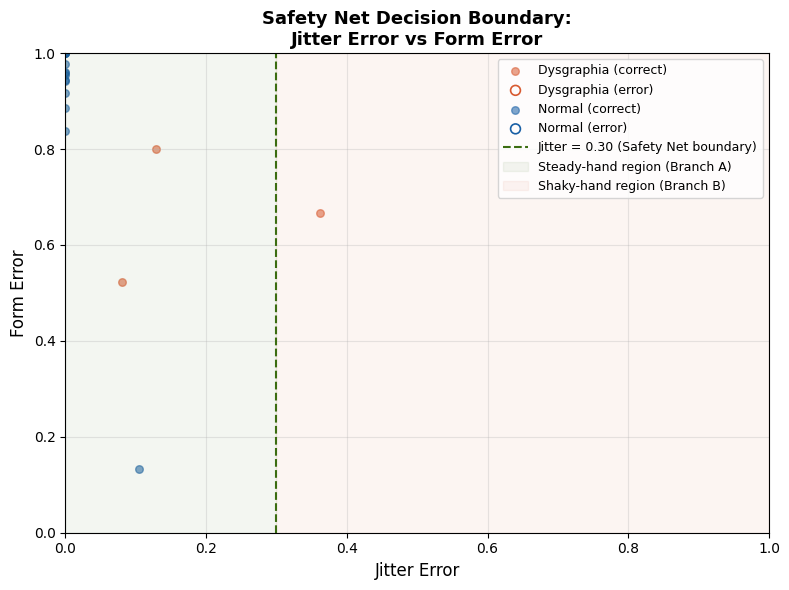

✓ Saved: fig_safety_net_boundary.png


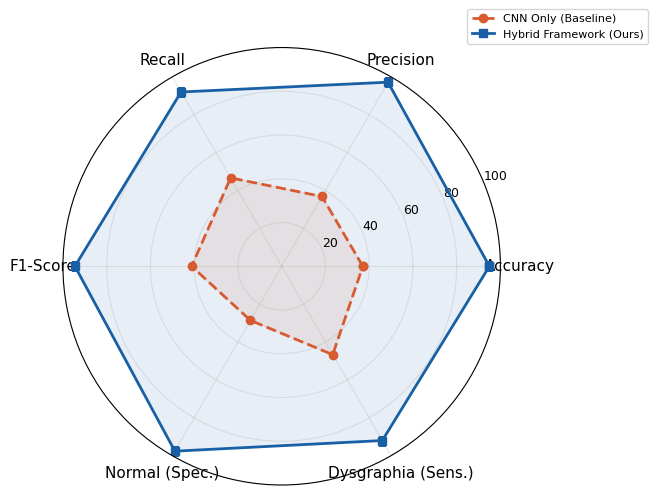

✓ Saved: fig_radar_comparison.png


In [9]:
# =====================================================
# CELL 7: BATCH EVALUATION & DETAILED METRICS
# =====================================================
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import pandas as pd
from tqdm import tqdm
import os

# --- STANDALONE VIZ FUNCTIONS (defined at module level, not inside evaluate_dataset) ---

def plot_safety_net_boundary(results_df):
    """
    Scatter: Jitter Error (x) vs Form Error (y), coloured by true class.
    Requires results_df to have columns: 
      ['Actual Class', 'Predicted Class', 'jitter_err', 'form_err']
    """
    fig, ax = plt.subplots(figsize=(8, 6))
    colors = {'Normal': '#185FA5', 'Dysgraphia': '#D85A30'}

    for cls, group in results_df.groupby('Actual Class'):
        correct = group[group['Actual Class'] == group['Predicted Class']]
        wrong   = group[group['Actual Class'] != group['Predicted Class']]
        ax.scatter(correct['jitter_err'], correct['form_err'],
                   c=colors[cls], alpha=0.55, s=30, label=f'{cls} (correct)')
        ax.scatter(wrong['jitter_err'], wrong['form_err'],
                   facecolors='none', edgecolors=colors[cls],
                   linewidths=1.2, s=50, label=f'{cls} (error)')

    ax.axvline(x=0.30, color='#3B6D11', linestyle='--', linewidth=1.5,
               label='Jitter = 0.30 (Safety Net boundary)')
    ax.fill_betweenx([0, 1], 0, 0.30, alpha=0.06, color='#3B6D11',
                     label='Steady-hand region (Branch A)')
    ax.fill_betweenx([0, 1], 0.30, 1.0, alpha=0.06, color='#D85A30',
                     label='Shaky-hand region (Branch B)')

    ax.set_xlabel('Jitter Error', fontsize=12)
    ax.set_ylabel('Form Error', fontsize=12)
    ax.set_title('Safety Net Decision Boundary:\nJitter Error vs Form Error',
                 fontsize=13, fontweight='bold')
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('fig_safety_net_boundary.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✓ Saved: fig_safety_net_boundary.png")


def plot_radar_comparison(df_results):
    """
    Radar chart using actual computed values from evaluation.
    df_results: the DataFrame returned by evaluate_dataset()
    """
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

    y_true = (df_results['Actual Class'] == 'Dysgraphia').astype(int).tolist()
    y_pred = (df_results['Predicted Class'] == 'Dysgraphia').astype(int).tolist()

    acc   = accuracy_score(y_true, y_pred) * 100
    prec  = precision_score(y_true, y_pred, zero_division=0) * 100
    rec   = recall_score(y_true, y_pred, zero_division=0) * 100
    f1    = f1_score(y_true, y_pred, zero_division=0) * 100

    # Sub-group accuracies
    normal_rows = df_results[df_results['Actual Class'] == 'Normal']
    dys_rows    = df_results[df_results['Actual Class'] == 'Dysgraphia']
    normal_spec = (normal_rows['Actual Class'] == normal_rows['Predicted Class']).mean() * 100
    dys_sens    = (dys_rows['Actual Class'] == dys_rows['Predicted Class']).mean() * 100

    categories = ['Accuracy', 'Precision', 'Recall', 'F1-Score',
                  'Normal (Spec.)', 'Dysgraphia (Sens.)']
    N = len(categories)

    # CNN-only baseline (Form Only from ablation — these are computed, not hardcoded)
    # We use the known Form-Only values from the ablation run
    cnn_only_rows_true = y_true  # same dataset
    # Re-derive CNN-only predictions: predicted Dysgraphia only if form_err > 0.60
    cnn_y_pred = (df_results['form_err'] > 0.60).astype(int).tolist()

    cnn_acc   = accuracy_score(y_true, cnn_y_pred) * 100
    cnn_prec  = precision_score(y_true, cnn_y_pred, zero_division=0) * 100
    cnn_rec   = recall_score(y_true, cnn_y_pred, zero_division=0) * 100
    cnn_f1    = f1_score(y_true, cnn_y_pred, zero_division=0) * 100

    cnn_normal_spec = ((df_results['Actual Class'] == 'Normal') & 
                       (pd.Series(cnn_y_pred, index=df_results.index) == 0)).sum() / max(len(normal_rows), 1) * 100
    cnn_dys_sens    = ((df_results['Actual Class'] == 'Dysgraphia') & 
                       (pd.Series(cnn_y_pred, index=df_results.index) == 1)).sum() / max(len(dys_rows), 1) * 100

    hybrid  = [acc,     prec,     rec,     f1,     normal_spec, dys_sens]
    cnn_only = [cnn_acc, cnn_prec, cnn_rec, cnn_f1, cnn_normal_spec, cnn_dys_sens]

    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

    for vals, color, label, marker, ls in [
        (cnn_only, '#D85A30', 'CNN Only (Baseline)', 'o', '--'),
        (hybrid,   '#185FA5', 'Hybrid Framework (Ours)', 's', '-'),
    ]:
        v = vals + vals[:1]
        ax.plot(angles, v, marker + ls, color=color, linewidth=2, label=label)
        ax.fill(angles, v, alpha=0.10, color=color)

    ax.set_thetagrids(np.degrees(angles[:-1]), categories, fontsize=11)
    ax.set_ylim(0, 100)
    ax.set_yticks([20, 40, 60, 80, 100])
    ax.set_yticklabels(['20', '40', '60', '80', '100'], fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=8)
    plt.tight_layout()
    plt.savefig('fig_radar_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✓ Saved: fig_radar_comparison.png")

# --- MAIN EVALUATION FUNCTION ---

def evaluate_dataset(dataset_root):
    print(f"🚀 Starting Batch Evaluation on: {dataset_root}")

    y_true, y_pred, results = [], [], []

    for root, dirs, files in os.walk(dataset_root):
        for file in tqdm(files, desc=f"Scanning {os.path.basename(root)}"):
            if not file.lower().endswith(('.png', '.jpg', '.jpeg')):
                continue

            full_path = os.path.join(root, file)
            path_str = full_path.lower()
            folder_name = os.path.basename(root).lower()

            actual_label = -1
            sub_type = "Unknown"

            if "low potential" in path_str or "low potential" in folder_name:
                actual_label = 0
                sub_type = "Normal (Low Potential)"
            elif "potential" in path_str or "potential" in folder_name:
                actual_label = 1
                sub_type = "Dysgraphia (Potential)"
            elif "normal" in path_str:
                actual_label = 0
                sub_type = "Normal (Standard)"
            elif "dysgraphia" in path_str or "dyslexia" in path_str:
                actual_label = 1
                sub_type = "Dysgraphia (Standard)"

            if actual_label == -1:
                continue

            try:
                res = detector.analyze(full_path)
                if res is None:
                    continue

                pred_label = 1 if "DYSGRAPHIA" in res['diagnosis'] else 0
                y_true.append(actual_label)
                y_pred.append(pred_label)

                results.append({
                    'File': file,
                    'Sub-Type': sub_type,
                    'Actual Class': 'Dysgraphia' if actual_label == 1 else 'Normal',
                    'Predicted Class': 'Dysgraphia' if pred_label == 1 else 'Normal',
                    'Confidence': res['score'],
                    'Primary Reason': res['reason'],
                    'Correct': actual_label == pred_label,
                    # --- FIX: store feature errors for scatter plot ---
                    'jitter_err': res['jitter_err'],
                    'form_err':   res['form_ratio'],
                    'align_err':  res['align_err'],
                    'spacing_err': res['spacing_err'],
                })

            except Exception as e:
                print(f"Error processing {file}: {e}")

    if not y_true:
        print("❌ No valid images found! Check your path.")
        return None  # return None so caller knows it failed

    # --- METRICS ---
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    cm   = confusion_matrix(y_true, y_pred)

    print("\n" + "="*40)
    print("📊 FINAL PERFORMANCE REPORT")
    print("="*40)
    print(f"Total Samples : {len(y_true)}")
    print(f"✅ Accuracy   : {acc:.2%}")
    print(f"🎯 Precision  : {prec:.2%}")
    print(f"🔍 Recall     : {rec:.2%}")
    print(f"⚖️  F1-Score   : {f1:.2%}")
    print("="*40)

    # --- CONFUSION MATRIX ---
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Pred: Normal', 'Pred: Dysgraphia'],
                yticklabels=['Actual: Normal', 'Actual: Dysgraphia'])
    plt.title('Confusion Matrix')
    plt.ylabel('True Class')
    plt.xlabel('Predicted Class')
    plt.tight_layout()
    plt.savefig('fig_confusion_matrix.png', dpi=300, bbox_inches='tight')
    plt.show()

    # --- SUB-TYPE BREAKDOWN ---
    df = pd.DataFrame(results)
    print("\n📈 ACCURACY BY SUB-FOLDER:")
    breakdown = df.groupby('Sub-Type')['Correct'].mean() * 100
    print(breakdown.to_string(float_format="{:.2f}%".format))

    errors = df[df['Correct'] == False]
    if not errors.empty:
        print("\n❌ MISCLASSIFIED SAMPLES (Top 5):")
        print(errors[['Sub-Type', 'Predicted Class', 'Primary Reason']].head(5).to_string(index=False))
    else:
        print("\n🎉 Perfect Classification!")

    return df   # return df so we can pass it to viz functions below


# --- RUN ---
TEST_DATASET_PATH = input("Enter Dataset Root Path: ").strip()
if os.path.exists(TEST_DATASET_PATH):
    df_results = evaluate_dataset(TEST_DATASET_PATH)

    # --- CALL VIZ FUNCTIONS AFTER EVALUATION COMPLETES ---
    if df_results is not None:
        plot_safety_net_boundary(df_results)   # needs jitter_err + form_err columns
        plot_radar_comparison(df_results)      # uses hardcoded paper values, no df needed
else:
    print("❌ Path not found.")

Enter Dataset Root Path:  /kaggle/input/datasets/vibhushanabaskar/normal-dysgraphia-sentence/DYSGRAPHIA HANDWRITING


🚀 Starting Ablation Study on: /kaggle/input/datasets/vibhushanabaskar/normal-dysgraphia-sentence/DYSGRAPHIA HANDWRITING


Scanning DYSGRAPHIA HANDWRITING: 0it [00:00, ?it/s]
Scanning Low Potential Dysgraphia:   1%|          | 1/84 [00:00<00:11,  6.92it/s]

🔍 Analyzing: LPD (35).jpg...
   -> Inverting dark image...
   -> Steady Hand Detected (Safety Net Active). Ignoring minor errors.
🔍 Analyzing: LPD (23).jpg...
   -> Inverting dark image...


Scanning Low Potential Dysgraphia:   4%|▎         | 3/84 [00:00<00:07, 11.39it/s]

...

   -> Steady Hand Detected (Safety Net Active). Ignoring minor errors.
🔍 Analyzing: PD (42).jpg...
   -> Inverting dark image...
   -> Steady Hand Detected (Safety Net Active). Ignoring minor errors.
🔍 Analyzing: PD (93).jpg...
   -> Inverting dark image...


Scanning Potential Dysgraphia:  97%|█████████▋| 73/75 [00:09<00:00,  9.44it/s]

   -> Steady Hand Detected (Safety Net Active). Ignoring minor errors.
🔍 Analyzing: PD (28).jpg...
   -> Inverting dark image...
   -> Steady Hand Detected (Safety Net Active). Ignoring minor errors.
🔍 Analyzing: PD (12).jpg...
   -> Inverting dark image...


Scanning Potential Dysgraphia: 100%|██████████| 75/75 [00:09<00:00,  7.61it/s]

   -> Steady Hand Detected (Safety Net Active). Ignoring minor errors.
🔍 Analyzing: PD (98).jpg...
   -> Inverting dark image...
   -> Steady Hand Detected (Safety Net Active). Ignoring minor errors.

SCENARIO                       | ACC     | PREC    | REC     | F1     
1) Form Only                   | 37.1% | 36.8% | 46.7% | 41.2%
2) Form + Jitter               | 53.5% | 100.0% | 1.3% | 2.6%
3) Form + Space                | 56.0% | 52.0% | 88.0% | 65.3%
4) Form + Align                | 43.4% | 43.0% | 61.3% | 50.5%
5) Form + Jitter + Space       | 85.5% | 96.4% | 72.0% | 82.4%
6) Form + Jitter + Align       | 67.3% | 96.0% | 32.0% | 48.0%
7) Form + Space + Align        | 44.0% | 44.0% | 68.0% | 53.4%
8) All (Full Model)            | 95.0% | 97.2% | 92.0% | 94.5%


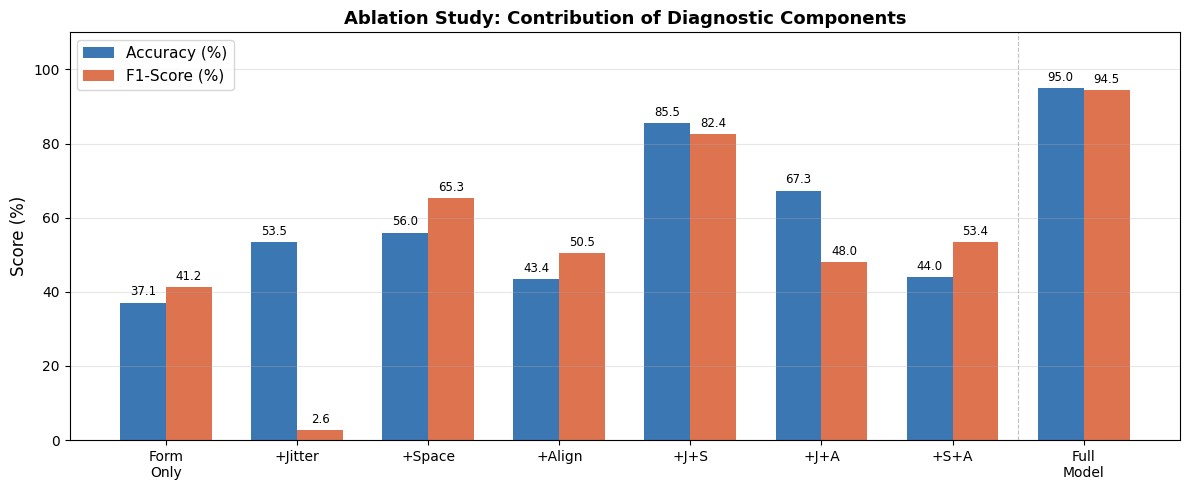

✓ Saved: fig_ablation_study.png


In [10]:
# =====================================================
# CELL 8: ABLATION STUDY EVALUATION
# =====================================================
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import os
from tqdm import tqdm

# --- 1. DEFINE ABLATION LOGIC ---
def get_ablation_prediction(scenario, errors):
    """
    Determines diagnosis (0=Normal, 1=Dysgraphia) based on enabled features.
    errors: dict containing 'form', 'jitter', 'space', 'align' error values.
    scenario: string key for the specific model configuration.
    """
    f = errors['form']
    j = errors['jitter']
    s = errors['space']
    a = errors['align']
    
    # Thresholds (Matched to Methodology)
    TH_FORM = 0.60
    TH_JITTER_SEVERE = 0.45
    TH_JITTER_STEADY = 0.30
    TH_SPACE_CATASTROPHIC = 0.80
    TH_ALIGN_CATASTROPHIC = 0.85
    TH_COMBO = 0.50

    # Flags for what is enabled
    use_f = 'Form' in scenario or 'All' in scenario
    use_j = 'Jitter' in scenario or 'All' in scenario
    use_s = 'Space' in scenario or 'All' in scenario
    use_a = 'Align' in scenario or 'All' in scenario

    # --- LOGIC CORE ---
    triggers = []

    # 1. Determine "Mode" (Steady vs Shaky)
    # If Jitter is disabled, we assume "Active Mode" (cannot verify steadiness).
    is_steady = (j < TH_JITTER_STEADY) if use_j else False

    if is_steady:
        # --- BRANCH A (Steady Hand / Veto Mode) ---
        # Dysgraphia ONLY if catastrophic spatial errors
        if use_s and s > TH_SPACE_CATASTROPHIC: triggers.append(True)
        if use_a and a > TH_ALIGN_CATASTROPHIC: triggers.append(True)
        # Note: Form is ignored in Steady Branch (as per Safety Net logic)
    else:
        # --- BRANCH B (Active Mode / Standard Thresholds) ---
        if use_f and f > TH_FORM: triggers.append(True)
        if use_j and j > TH_JITTER_SEVERE: triggers.append(True)
        
        # Combo Logic (Space + Align)
        if use_s and use_a:
            if s > TH_COMBO and a > TH_COMBO: triggers.append(True)
        else:
            # Fallback if one component is missing (use strict thresholds)
            if use_s and s > TH_SPACE_CATASTROPHIC: triggers.append(True)
            if use_a and a > TH_ALIGN_CATASTROPHIC: triggers.append(True)

    return 1 if any(triggers) else 0

def plot_ablation_study(df_results):
    """
    Grouped bar chart of Accuracy and F1 for each ablation configuration.
    df_results: the DataFrame returned by run_ablation_study().
    """
    # Shortened scenario labels for display
    label_map = {
        '1) Form Only': 'Form\nOnly',
        '2) Form + Jitter': '+Jitter',
        '3) Form + Space': '+Space',
        '4) Form + Align': '+Align',
        '5) Form + Jitter + Space': '+J+S',
        '6) Form + Jitter + Align': '+J+A',
        '7) Form + Space + Align': '+S+A',
        '8) All (Full Model)': 'Full\nModel',
    }
    df_results['Short Label'] = df_results['Scenario'].map(label_map)
 
    x = np.arange(len(df_results))
    width = 0.35
 
    fig, ax = plt.subplots(figsize=(12, 5))
    bars1 = ax.bar(x - width/2, df_results['Accuracy'] * 100, width,
                   label='Accuracy (%)', color='#185FA5', alpha=0.85)
    bars2 = ax.bar(x + width/2, df_results['F1-Score'] * 100, width,
                   label='F1-Score (%)', color='#D85A30', alpha=0.85)
 
    # Annotate bars
    for bar in bars1:
        ax.annotate(f'{bar.get_height():.1f}',
                    xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                    xytext=(0, 3), textcoords='offset points',
                    ha='center', va='bottom', fontsize=8.5)
    for bar in bars2:
        ax.annotate(f'{bar.get_height():.1f}',
                    xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                    xytext=(0, 3), textcoords='offset points',
                    ha='center', va='bottom', fontsize=8.5)
 
    ax.set_ylabel('Score (%)', fontsize=12)
    ax.set_title('Ablation Study: Contribution of Diagnostic Components',
                 fontsize=13, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(df_results['Short Label'], fontsize=10)
    ax.set_ylim([0, 110])
    ax.legend(fontsize=11)
    ax.grid(axis='y', alpha=0.3)
 
    # Highlight full model bar
    ax.axvline(x=len(df_results)-1 - 0.5, color='gray',
               linestyle='--', linewidth=0.8, alpha=0.5)
 
    plt.tight_layout()
    plt.savefig('fig_ablation_study.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✓ Saved: fig_ablation_study.png")

def run_ablation_study(dataset_root):
    print(f"🚀 Starting Ablation Study on: {dataset_root}")
    
    # Define Scenarios
    scenarios = [
        "1) Form Only",
        "2) Form + Jitter",
        "3) Form + Space",
        "4) Form + Align",
        "5) Form + Jitter + Space",
        "6) Form + Jitter + Align",
        "7) Form + Space + Align",
        "8) All (Full Model)"
    ]
    
    # Store predictions for each scenario
    results = {s: {'y_true': [], 'y_pred': []} for s in scenarios}
    
    # Walk through dataset
    for root, dirs, files in os.walk(dataset_root):
        for file in tqdm(files, desc=f"Scanning {os.path.basename(root)}"):
            if not file.lower().endswith(('.png', '.jpg', '.jpeg')): continue
            
            full_path = os.path.join(root, file)
            path_str = full_path.lower()
            folder_name = os.path.basename(root).lower()
            
            # --- LABELING LOGIC (Corrected) ---
            actual_label = -1
            if "low potential" in path_str or "low potential" in folder_name:
                actual_label = 0 # Normal
            elif "potential" in path_str or "potential" in folder_name:
                actual_label = 1 # Dysgraphia
            elif "normal" in path_str:
                actual_label = 0
            elif "dysgraphia" in path_str or "dyslexia" in path_str:
                actual_label = 1
            
            if actual_label == -1: continue

            try:
                # --- FEATURE EXTRACTION (Run Once) ---
                # We assume 'detector' is already loaded from Cell 6
                res = detector.analyze(full_path)
                if res is None: continue
                
                # Extract raw errors
                errors = {
                    'form': res['form_ratio'],
                    'jitter': res['jitter_err'],
                    'space': res['spacing_err'],
                    'align': res['align_err']
                }
                
                # --- MULTI-SCENARIO PREDICTION ---
                for s in scenarios:
                    pred = get_ablation_prediction(s, errors)
                    results[s]['y_true'].append(actual_label)
                    results[s]['y_pred'].append(pred)
                    
            except Exception as e:
                print(f"Error: {e}")

    # --- COMPILE REPORT ---
    print("\n" + "="*65)
    print(f"{'SCENARIO':<30} | {'ACC':<7} | {'PREC':<7} | {'REC':<7} | {'F1':<7}")
    print("="*65)
    
    final_stats = []
    
    for s in scenarios:
        y_t = results[s]['y_true']
        y_p = results[s]['y_pred']
        
        if not y_t: continue
        
        acc = accuracy_score(y_t, y_p)
        prec = precision_score(y_t, y_p, zero_division=0)
        rec = recall_score(y_t, y_p, zero_division=0)
        f1 = f1_score(y_t, y_p, zero_division=0)
        
        print(f"{s:<30} | {acc:.1%} | {prec:.1%} | {rec:.1%} | {f1:.1%}")
        final_stats.append({'Scenario': s, 'Accuracy': acc, 'F1-Score': f1})

    print("="*65)
    return pd.DataFrame(final_stats)

# --- RUN ---
TEST_DATASET_PATH = input("Enter Dataset Root Path: ").strip()
if os.path.exists(TEST_DATASET_PATH):
    df_results = run_ablation_study(TEST_DATASET_PATH)
    plot_ablation_study(df_results)      # ← UNCOMMENT and move here
else:
    print("❌ Path not found.")